In [18]:
%pip install -U -q numpy pandas wfdb matplotlib notebook

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np
import os

## Sekcja wczytwania


In [20]:
data_dir = 'charis-database-1.0.0'  # Lokalny folder
record_name = 'charis6'     # Nazwa rekordu (.hea i .dat)

os.makedirs(data_dir, exist_ok=True)

Rekord: charis6
Długość: 8279982 próbek (46.0 h)
fs: 50 Hz, Kanały: 3
Nazwy kanałów: ['ABP', 'ECG', 'ICP']


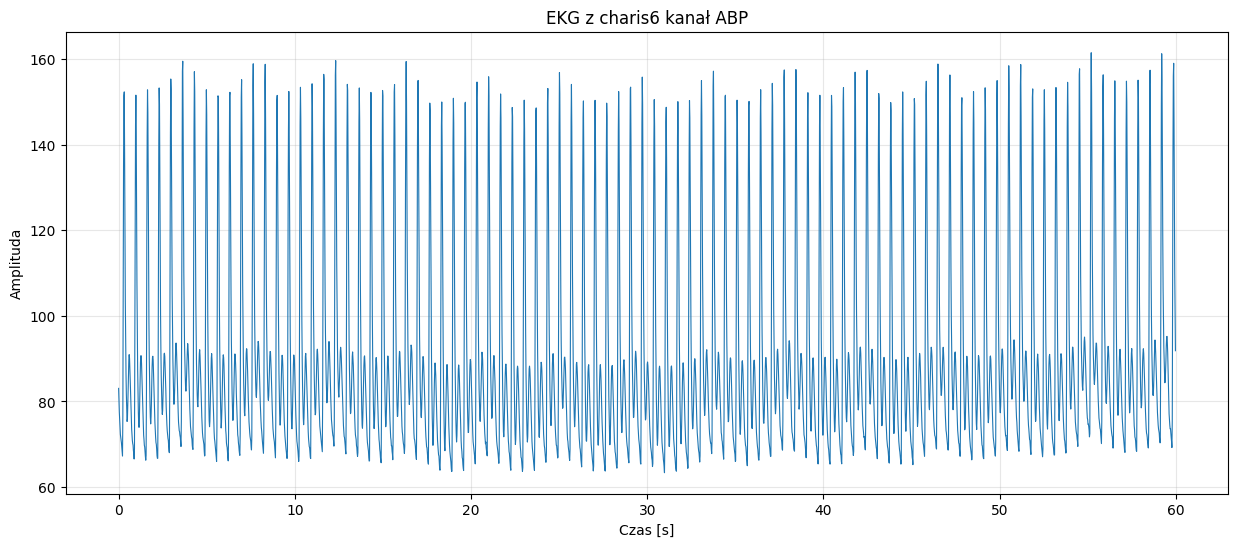

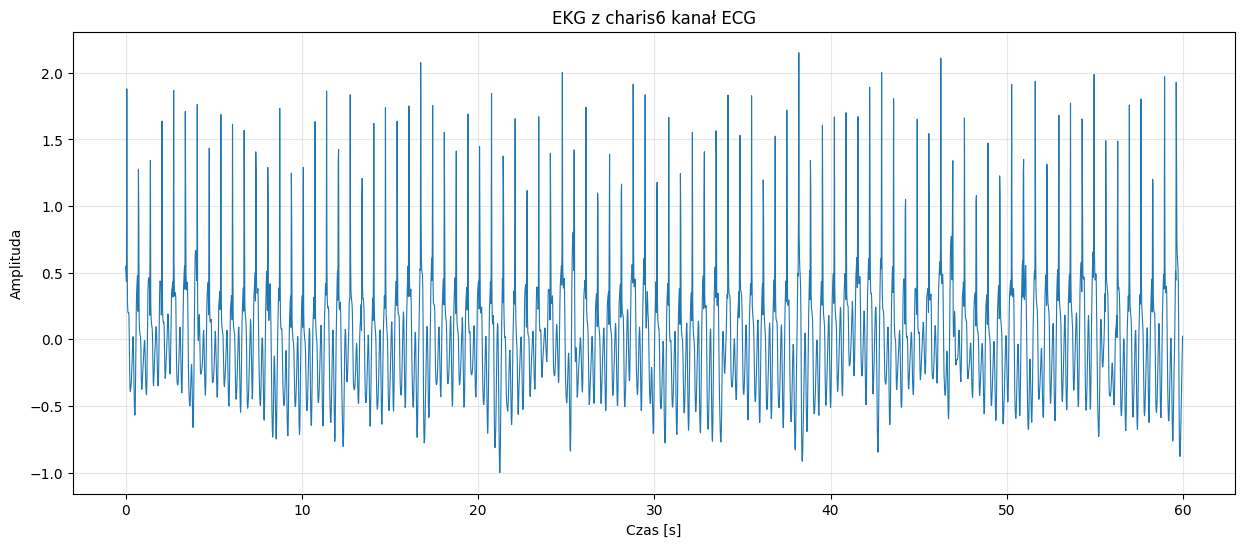

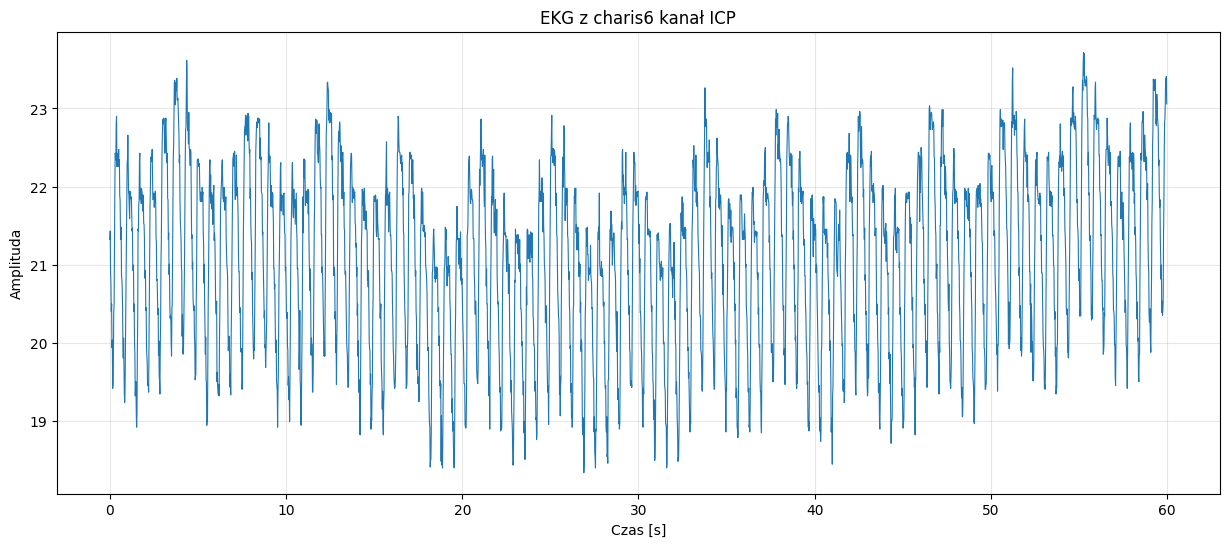

In [ ]:
# TERAZ TWÓJ KOD BEZ ZMIAN
local_path = os.path.join(data_dir, record_name)

# Odczyt (automatycznie znajdzie .hea i .dat)
record = wfdb.rdrecord(local_path)

# Dane sygnałów
signals = record.p_signal  # NxM tablica (próbki x kanały)
fs = record.fs  # Częstotliwość próbkowania
time = np.arange(len(signals)) / fs

print(f"Rekord: {record_name}")
print(f"Długość: {len(signals)} próbek ({len(signals)/fs/3600:.1f} h)")
print(f"fs: {fs} Hz, Kanały: {record.n_sig}")
print(f"Nazwy kanałów: {record.sig_name}")  # np. ['MCG', 'ABP', 'ICP']

# EKG/ECG (dostosuj indeks kanału)
for ecg_channel in range (0,3): # Lub 1 dla ECG w CHARIS
    ecg = signals[:, ecg_channel]

    # Wizualizacja pierwszych 60s
    plt.figure(figsize=(15, 6))
    plt.plot(time[:int(60*fs)], ecg[:int(60*fs)], linewidth=0.8)
    plt.xlabel('Czas [s]')
    plt.ylabel('Amplituda')
    plt.title(f'EKG z {record_name} kanał {record.sig_name[ecg_channel]}')
    plt.grid(True, alpha=0.3)
    plt.show()





# Zapis do CSV (opcjonalnie)
# np.savetxt('ecg_data.csv', np.column_stack([time, ecg]), delimiter=',', 
#            header='time_s,ecg_mv', comments='')


Rekord: charis6
Długość: 8279982 próbek (46.0 h)
fs: 50 Hz, Kanały: 3
Nazwy kanałów: ['ABP', 'ECG', 'ICP']


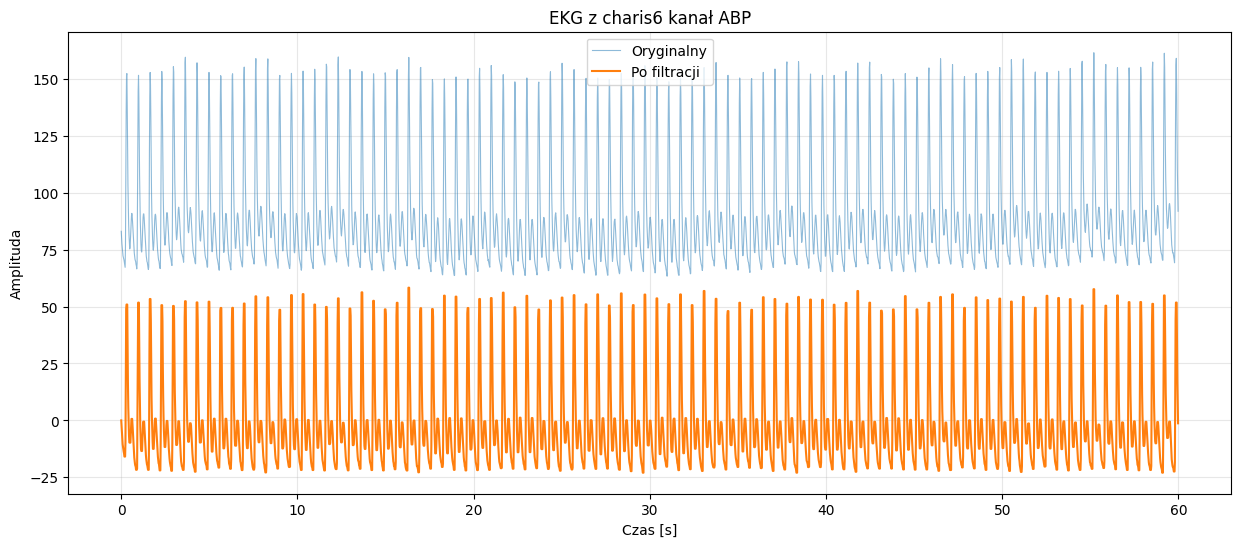

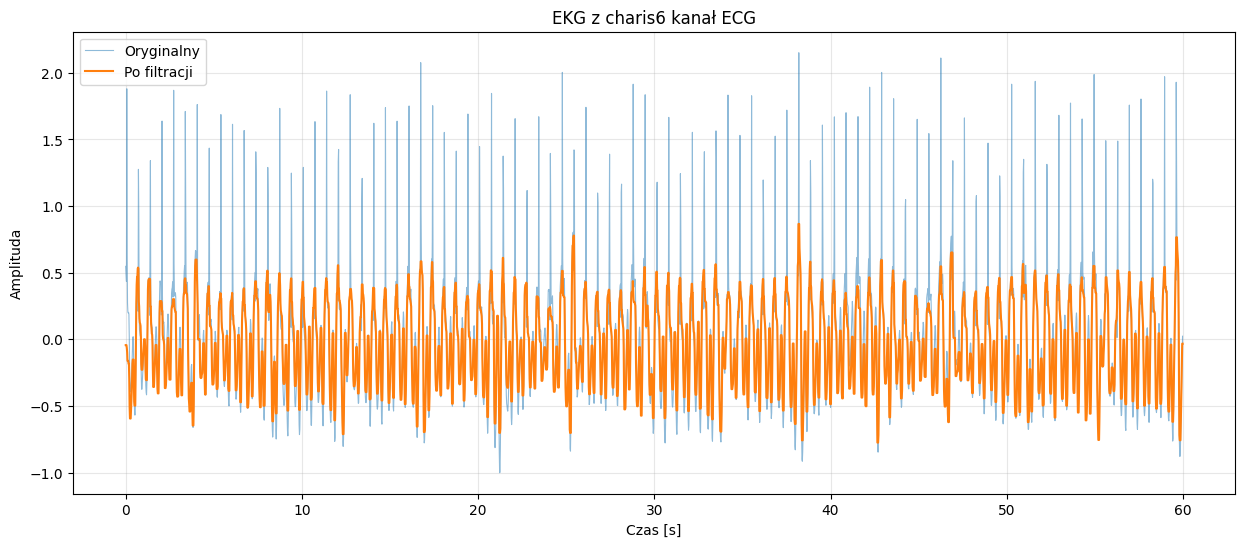

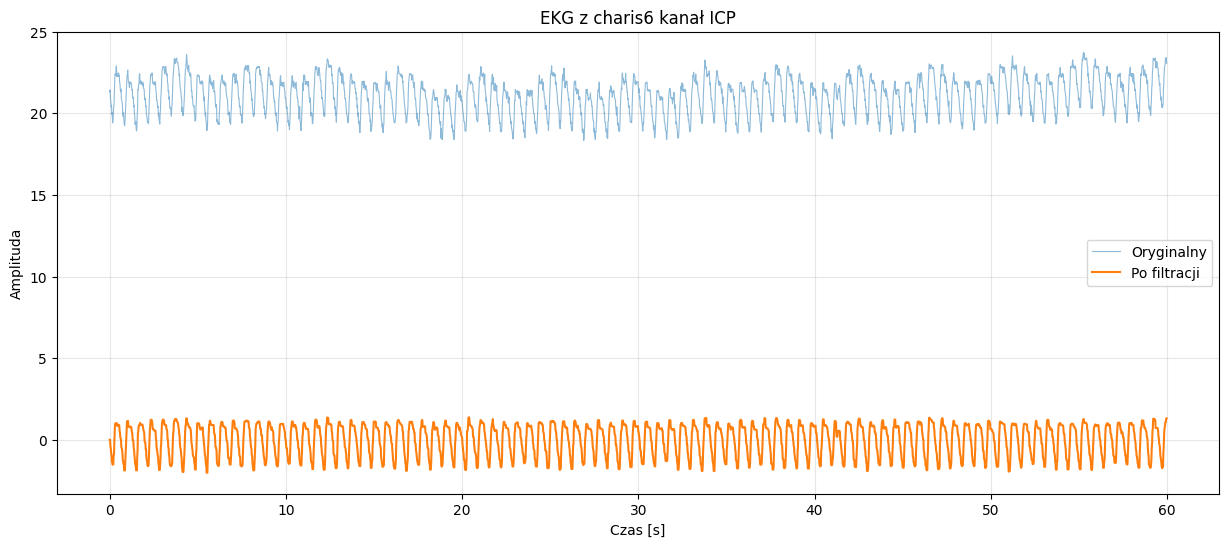

In [ ]:
import os
import numpy as np
import wfdb
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, medfilt

# --- Funkcja filtru ---
def bandpass_filter(signal, fs, lowcut=0.5, highcut=40, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

# TERAZ TWÓJ KOD (lekko rozszerzony)
local_path = os.path.join(data_dir, record_name)

record = wfdb.rdrecord(local_path)

signals = record.p_signal
fs = record.fs
time = np.arange(len(signals)) / fs

print(f"Rekord: {record_name}")
print(f"Długość: {len(signals)} próbek ({len(signals)/fs/3600:.1f} h)")
print(f"fs: {fs} Hz, Kanały: {record.n_sig}")
print(f"Nazwy kanałów: {record.sig_name}")

# EKG/ECG
for ecg_channel in range(0, 3):
    ecg = signals[:, ecg_channel]

    # --- FILTRACJA ---
    ecg_filtered = bandpass_filter(ecg, fs)
    ecg_filtered = medfilt(ecg_filtered, kernel_size=5)  # opcjonalne wygładzenie

    # --- Wizualizacja ---
    plt.figure(figsize=(15, 6))
    
    plt.plot(time[:int(60*fs)], ecg[:int(60*fs)], 
             label='Oryginalny', alpha=0.5, linewidth=0.8)
    
    plt.plot(time[:int(60*fs)], ecg_filtered[:int(60*fs)], 
             label='Po filtracji', linewidth=1.5)
    
    plt.xlabel('Czas [s]')
    plt.ylabel('Amplituda')
    plt.title(f'EKG z {record_name} kanał {record.sig_name[ecg_channel]}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()